Проект: Статистический анализ данных. Анализ аренды самокатов

Введение: Добро пожаловать в проект статистического анализа данных о известной службе проката самокатов GoFast. Целью этого проекта является анализ пользовательских данных из разных городов, их действий в поездках и моделей подписки, чтобы выявить идеи, которые могут способствовать росту бизнеса. 
Пользователи GoFast используют мобильное приложение для поездок по городу с опциями как для подписки, так и для бесплатного использования. Структура ценообразования включает в себя поминутную оплату и плату за начальную поездку, которая варьируется в зависимости от типа подписки. Набор данных содержит информацию о пользователях, их поездках и сведениях о подписке. Пользователи идентифицируются по уникальным идентификаторам пользователей с дополнительными атрибутами, такими как имя, возраст, город и тип подписки. Данные о поездке включают пройденное расстояние, продолжительность поездки и дату поездки. Данные о подписке содержат подробную информацию о ценах для различных типов подписки. 
без подписки
абонентская плата отсутствует;
стоимость одной минуты поездки — 8 рублей;
стоимость старта (начала поездки) — 50 рублей;
с подпиской Ultra
абонентская плата — 199;
199 рублей в месяц;
стоимость одной минуты поездки — 6 рублей;
стоимость старта — бесплатно.
Описание данных
В основных данных есть информация о пользователях, их поездках и подписках.
Пользователи — users_go.csv
user_id	уникальный идентификатор пользователя
name	имя пользователя
age	возраст
city	город
subscription_type	тип подписки (free, ultra)
Поездки — rides_go.csv
user_id	уникальный идентификатор пользователя
distance	расстояние, которое пользователь проехал в текущей сессии (в метрах)
duration	продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»
date	дата совершения поездки
Подписки — subscriptions_go.csv
subscription_type	тип подписки
minute_price	стоимость одной минуты поездки по данной подписке
start_ride_price	стоимость начала поездки
subscription_fee	стоимость ежемесячного платежа

Проект будет включать в себя несколько ключевых этапов:
1. Загрузка данных: мы загрузим файлы CSV, содержащие данные о пользователях, поездках и подписках, используя библиотеку pandas, и проверим исходную информацию в каждом dataframe. 
2. Предварительная обработка данных: задачи включают преобразование столбца даты в тип даты и времени pandas, создание нового столбца для месяца, а также обработку пропущенных значений и дубликатов.
3. Исследовательский анализ данных: мы будем изучать и визуализировать информацию о пользователях и поездках, включая частоту поездок в городах, возраст пользователей, пройденное расстояние за поездку и продолжительность поездки.
4. Интеграция данных: объединение данных о пользователях, поездках и подписках в единый фрейм данных и создание отдельных фреймов данных для пользователей с подписками и без них.
5. Расчет дохода: агрегирование данных о поездках для расчета общего расстояния, количества поездок, общего времени на пользователя в месяц и добавление столбца для ежемесячного дохода на пользователя.
6. Проверка гипотез: оценка гипотез, связанных с поведением пользователей, расстоянием поездки, сравнением ежемесячных доходов между типами подписок и влиянием технических обновлений на взаимодействие со службой поддержки.

Посредством этого комплексного анализа постараемся предоставить GoFast полезную информацию для улучшения пользовательского опыта, оптимизации потоков доходов и стимулирования роста бизнеса.

**Описание даных**

Пользователи — users_go.csv
- user_id	уникальный идентификатор пользователя
- name	имя пользователя
- age	возраст
- city	город
- subscription_type	тип подписки (free, ultra)


Поездки — rides_go.csv
- user_id	уникальный идентификатор пользователя
- distance	расстояние, которое пользователь проехал в текущей сессии (в метрах)
- duration	продолжительность сессии (в минутах) — время с того момента, как пользователь нажал кнопку «Начать поездку» до момента, как он нажал кнопку «Завершить поездку»
- date	дата совершения поездки

Подписки — subscriptions_go.csv
- subscription_type	тип подписки
- minute_price	стоимость одной минуты поездки по данной подписке
- start_ride_price	стоимость начала поездки
- subscription_fee	стоимость ежемесячного платежа

In [1]:
# Подключаем библиотеки
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats as st
import seaborn as sns

In [2]:
# Чтобы видеть все колонки таблицы
pd.set_option('display.max_columns', None)

#### Шаг 1. Загрузка данных

In [ ]:
import pandas as pd

try:
    users = pd.read_csv('/datasets/users_go.csv')
    rides = pd.read_csv('/datasets/rides_go.csv')
    subscriptions = pd.read_csv('/datasets/subscriptions_go.csv')
except:
    try:
        users = pd.read_csv('datasets/users_go.csv')
        rides = pd.read_csv('datasets/rides_go.csv')
        subscriptions = pd.read_csv('datasets/subscriptions_go.csv')
    except:
        users = pd.read_csv('https://code.s3.yandex.net/datasets/users_go.csv')
        rides = pd.read_csv('https://code.s3.yandex.net/datasets/rides_go.csv')
        subscriptions = pd.read_csv('https://code.s3.yandex.net/datasets/subscriptions_go.csv')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1565 entries, 0 to 1564
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            1565 non-null   int64 
 1   name               1565 non-null   object
 2   age                1565 non-null   int64 
 3   city               1565 non-null   object
 4   subscription_type  1565 non-null   object
dtypes: int64(2), object(3)
memory usage: 61.3+ KB
None

           user_id          age
count  1565.000000  1565.000000
mean    762.633866    24.922045
std     443.260155     4.553496
min       1.000000    12.000000
25%     378.000000    22.000000
50%     762.000000    25.000000
75%    1146.000000    28.000000
max    1534.000000    43.000000



,user_id,name,age,city,subscription_type
0,1,Кира,22,Тюмень,ultra
1,2,Станислав,31,Омск,ultra
2,3,Алексей,20,Москва,ultra
3,4,Константин,26,Ростов-на-Дону,ultra
4,5,Адель,28,Омск,ultra
5,6,Регина,25,Краснодар,ultra
6,7,Игорь,23,Омск,ultra
7,8,Юрий,23,Краснодар,ultra
8,9,Ян,21,Пятигорск,ultra
9,10,Валерий,18,Екатеринбург,ultra


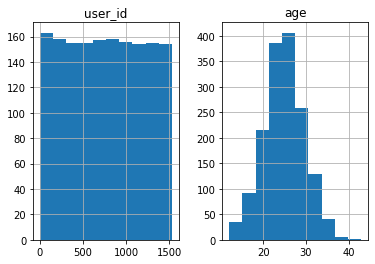

In [4]:
# Изучим датафрейм 'users' с построением гистрограммы
print(users.info()) 
print()
print(users.describe())
users.hist()
print()
users.head(10)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18068 entries, 0 to 18067
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   user_id   18068 non-null  int64  
 1   distance  18068 non-null  float64
 2   duration  18068 non-null  float64
 3   date      18068 non-null  object 
dtypes: float64(2), int64(1), object(1)
memory usage: 564.8+ KB
None

            user_id      distance      duration
count  18068.000000  18068.000000  18068.000000
mean     842.869936   3070.659976     17.805011
std      434.734317   1116.831209      6.091051
min        1.000000      0.855683      0.500000
25%      487.000000   2543.226360     13.597563
50%      889.000000   3133.609994     17.678395
75%     1213.250000   3776.222735     21.724800
max     1534.000000   7211.007745     40.823963


,user_id,distance,duration,date
0,1,4409.919140,25.599769,2021-01-01
1,1,2617.592153,15.816871,2021-01-18
2,1,754.159807,6.232113,2021-04-20
3,1,2694.783254,18.511000,2021-08-11
4,1,4028.687306,26.265803,2021-08-28
5,1,2770.890808,16.650138,2021-10-09
6,1,3039.020292,14.927879,2021-10-19
7,1,2842.118050,23.117468,2021-11-06
8,1,3412.690668,15.238072,2021-11-14
9,1,748.690645,15.041884,2021-11-22


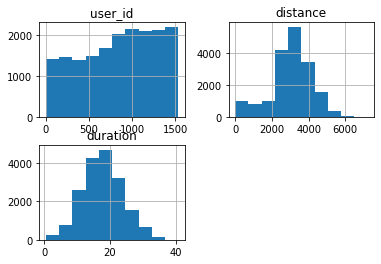

In [5]:
# Изучим датафрейм 'rides'
print(rides.info()) 
print()
print(rides.describe())
rides.hist()
rides.head(10)


In [6]:
# Изучим датафрейм 'subscriptions' 
print(subscriptions.info()) 
print()
print(subscriptions.describe())

subscriptions.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   subscription_type  2 non-null      object
 1   minute_price       2 non-null      int64 
 2   start_ride_price   2 non-null      int64 
 3   subscription_fee   2 non-null      int64 
dtypes: int64(3), object(1)
memory usage: 192.0+ bytes
None

       minute_price  start_ride_price  subscription_fee
count      2.000000          2.000000          2.000000
mean       7.000000         25.000000         99.500000
std        1.414214         35.355339        140.714249
min        6.000000          0.000000          0.000000
25%        6.500000         12.500000         49.750000
50%        7.000000         25.000000         99.500000
75%        7.500000         37.500000        149.250000
max        8.000000         50.000000        199.000000


,subscription_type,minute_price,start_ride_price,subscription_fee
0,free,8,50,0
1,ultra,6,0,199


Изучив данные видим, что нет пропусков. Нужно будет привести к подходящему типу данных столбец 'date'. На гистограммах данные выгляят нормально. Будем исследовать.

#### Шаг 2. Предобработка данных

In [7]:
# Столбец 'date' приведём к datetime
rides['date'] = pd.to_datetime(rides['date'], format='%Y-%m-%d')
rides['date']

0       2021-01-01
1       2021-01-18
2       2021-04-20
3       2021-08-11
4       2021-08-28
           ...    
18063   2021-11-04
18064   2021-11-16
18065   2021-11-18
18066   2021-11-27
18067   2021-12-29
Name: date, Length: 18068, dtype: datetime64[ns]

In [8]:
rides.duplicated().sum()

0

In [9]:
subscriptions.duplicated().sum()

0

In [10]:
users.duplicated().sum()

31

In [11]:
# Посмотрим на дубликаты
duplicates = users[users.duplicated()]
display("Дубликаты:")
display(duplicates)

'Дубликаты:'

,user_id,name,age,city,subscription_type
1534,293,Агата,26,Краснодар,ultra
1535,16,Амалия,27,Краснодар,ultra
1536,909,Константин,20,Екатеринбург,free
1537,403,Полина,19,Сочи,ultra
1538,908,Рустам,30,Тюмень,free
1539,43,Стефания,22,Омск,ultra
1540,127,Павел,25,Пятигорск,ultra
1541,659,Злата,27,Ростов-на-Дону,ultra
1542,204,Руслан,30,Пятигорск,ultra
1543,153,Герман,23,Москва,ultra


Дубликаты записаны подряд в самом конце датафрейма, скорее всего из-за человеческой ошибки или ошибки загрузки данных. Думаю т.к. они как будто приписаны к датафрейму, то это точно дубликаты и их можно удалить без ущерба для данных, к тому же их ещё и мало.

In [12]:
# Удаляем дубликаты и проверяем
users.drop_duplicates(inplace=True)
users.duplicated().sum()

0

In [13]:
# Проверим данные за какие годы данные, чтобы месяцы не пересеклись, если данные за несколько лет
rides['date'].dt.year.unique()

array([2021])

In [14]:
# Создадим столбец с месяцем т.к. данные всего за один год
rides['month'] = rides['date'].dt.month
rides['month'].head()

0    1
1    1
2    4
3    8
4    8
Name: month, dtype: int64

В итоге пропусков не было, дубликаты удалили, добавили столбец 'month' с номером месяца.

#### Шаг 3. Исследовательский анализ данных

Визуализируем данные о пользователях и поездках.

In [15]:
number_users_by_city = users['city'].value_counts()


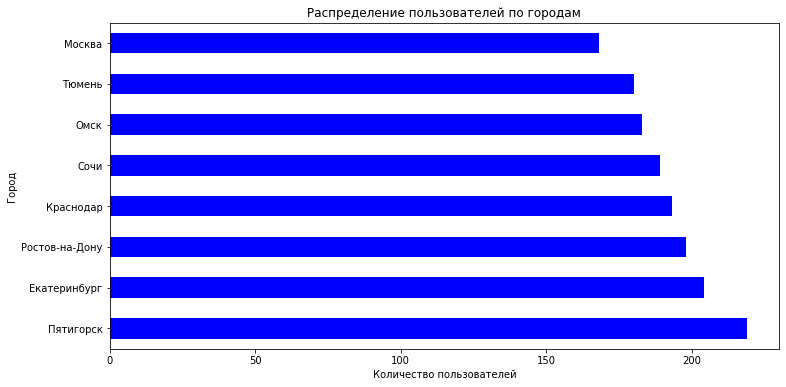

In [16]:
number_users_by_city = users['city'].value_counts()

# Сортируем по убыванию
number_users_by_city_sorted = number_users_by_city.sort_values(ascending=False)

# Строим горизонтальный барплот
plt.figure(figsize=(12, 6))  # Устанавливаем размер графика
number_users_by_city_sorted.plot(kind='barh', color='blue')

plt.title('Распределение пользователей по городам')
plt.xlabel('Количество пользователей')
plt.ylabel('Город')

plt.show()

In [17]:
number_sub = users['subscription_type'].value_counts()

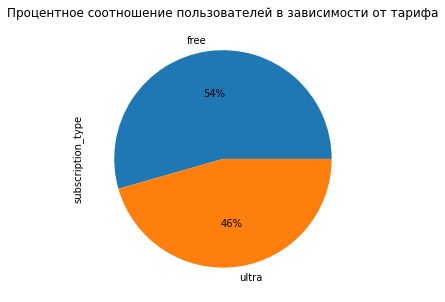

In [18]:
users['subscription_type'].value_counts().plot(
    kind = 'pie', 
    y = number_sub, 
    autopct = '%1.0f%%', 
    figsize=(5,5),
    title = 'Процентное соотношение пользователей в зависимости от тарифа');

Возраст пользователей

In [19]:
users['age'].sort_values().head(10)

664     12
66      12
727     12
34      12
235     13
1249    13
314     13
83      13
553     13
1241    13
Name: age, dtype: int64

In [20]:
users['age'].sort_values(ascending=False).head(10)

1201    43
961     39
804     38
453     38
383     38
205     37
848     37
721     36
1491    36
644     36
Name: age, dtype: int64

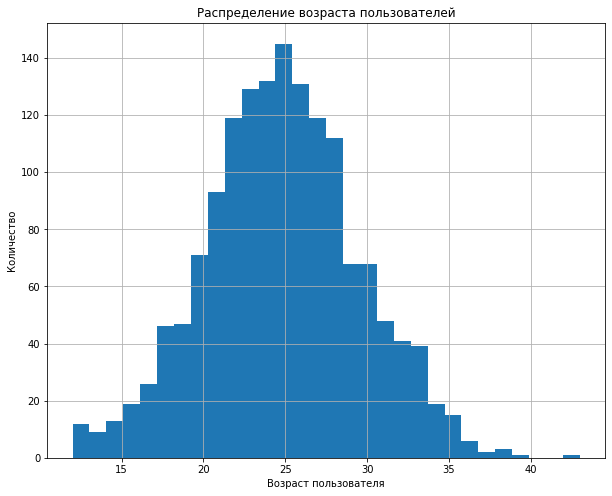

In [21]:
ax = users['age'].hist(figsize=(10, 8), bins=30)
ax.set_title('Распределение возраста пользователей')
ax.set_xlabel('Возраст пользователя')
ax.set_ylabel('Количество');

In [22]:
# Исследуем данные про поездки
display(round(rides['distance'].sort_values(), 2).head(10))
round(rides['distance'].sort_values(ascending=False), 2).head(10)

11555     0.86
9541      2.57
13690     4.33
8658      6.78
7841      7.10
8906     11.28
8324     12.23
13940    15.00
15626    15.37
11862    15.63
Name: distance, dtype: float64

16309    7211.01
16484    7066.00
15580    6908.49
17171    6760.94
17242    6724.93
10341    6671.97
11385    6601.20
12086    6538.94
10915    6535.39
11319    6503.60
Name: distance, dtype: float64

In [23]:
rides['distance'].describe()

count    18068.000000
mean      3070.659976
std       1116.831209
min          0.855683
25%       2543.226360
50%       3133.609994
75%       3776.222735
max       7211.007745
Name: distance, dtype: float64

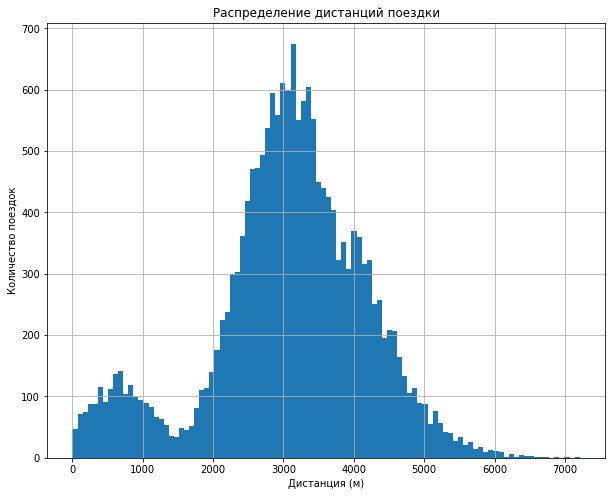

In [24]:
ax = rides['distance'].hist(bins=100, figsize=(10, 8))
ax.set_title('Распределение дистанций поездки')
ax.set_xlabel('Дистанция (м)')
ax.set_ylabel('Количество поездок');

In [25]:
# Самые короткие и длинные поездки
print(rides['duration'].sort_values().head(10))
rides['duration'].sort_values(ascending=False).head(10)

12013    0.5
17314    0.5
15029    0.5
7437     0.5
12967    0.5
15015    0.5
13012    0.5
7508     0.5
16589    0.5
9049     0.5
Name: duration, dtype: float64


4215    40.823963
4709    39.873856
2623    39.526602
1998    38.352763
6453    38.265229
143     38.125729
3729    37.014141
499     36.906491
6348    36.809310
4653    36.622595
Name: duration, dtype: float64

Посмотрим что за поездки по полминуты длинной

In [26]:
rides['duration'].value_counts()

0.500000     95
22.184080     1
25.866000     1
22.837062     1
19.173800     1
             ..
18.843765     1
17.644888     1
22.477965     1
19.745218     1
16.537044     1
Name: duration, Length: 17974, dtype: int64

In [27]:
rides[rides['duration'] == 0.5]

,user_id,distance,duration,date,month
6531,701,4196.445201,0.5,2021-08-31,8
6570,704,4830.824371,0.5,2021-10-14,10
6680,712,4684.004397,0.5,2021-03-04,3
6695,713,5215.642710,0.5,2021-02-25,2
6768,718,5197.436649,0.5,2021-02-11,2
...,...,...,...,...,...
17004,1460,5531.335845,0.5,2021-01-19,1
17242,1477,6724.932981,0.5,2021-01-12,1
17314,1483,4445.481070,0.5,2021-03-06,3
17505,1496,5722.551787,0.5,2021-02-14,2


Не заметил необычного ничего кроме одинакойвой длительности поездки в полминуты, она же минимальная, наверно на сервисе это минимальная возможная длина поездки.

In [28]:
rides.groupby(['user_id']).sum(numeric_only = True)

,distance,duration,month
user_id,,,
1,34070.182066,204.604909,99
2,33964.058614,197.644279,67
3,36907.597866,233.193513,66
4,44837.189916,288.563581,107
5,35556.949649,174.073932,51
...,...,...,...
1530,46758.469822,292.366839,104
1531,67054.794222,408.192206,142
1532,33902.203192,212.160144,111


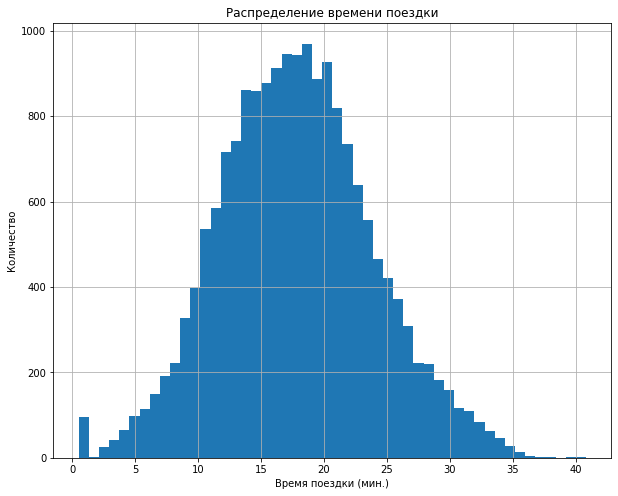

In [29]:
ax = rides['duration'].hist(bins=50, figsize=(10, 8))
ax.set_title('Распределение времени поездки')
ax.set_xlabel('Время поездки (мин.)')
ax.set_ylabel('Количество');

Вывод: Количество пользователей по городам распределено примерно одинаково, нет выдающихся значений. Лидером по количеству пользователей является Пятигорск - 219 пользователей. Меньше всего пользователей в Москве - 168. Связано это скорее всего с тем, что Москва более развитый в транспортном плане город и выбора видов транспорта больше.

Пользователей, использующих бесплатную подписку больше - 835 человек, что является ~54% от общего числа пользователей. Платной подпиской пользуются 699 пользователей, что соответственно является ~46% от общего числа пользователей.

Самыми младшими являются пользователи 12, 13 лет. Самыми старшими - 43, 39. В целом, пользователи приложения укладываются в промежуток от 20 до 30 лет, больше всего пользователей 25 лет.

Самая короткое расстояние поездки - 0.86 м и 2.57 м, самое длинное - 7.211 км. В основном пользователи проезжают от 2.5 км до 3.5 км.

Самые короткие поездки - по пол минуты. Наверняка это минимально возможная длительность поездки на сервисе. Самая длинная поездка заняла 40 минут.
В основном же длительность поездки состовляет ~ 13 - 22 минут.

    

#### Шаг 4. Объединение данных

Объединим данные о пользователях, поездках и подписках в один датафрейм.

In [30]:
full_data = users.merge(rides, on='user_id')
full_data = full_data.merge(subscriptions, on='subscription_type')
full_data

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,19.822962,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.423057,21.409799,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.185507,18.435051,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.308661,16.674362,2021-11-27,11,8,50,0


In [31]:
full_data.shape, users.shape, rides.shape, subscriptions.shape

((18068, 12), (1534, 5), (18068, 5), (2, 4))

Количество строк соответствует количеству строк наибольшего датафрейма.

In [32]:
# Проверим колонки: посчитаем сууму колонок и отнимем 2, так как две колонки объединяются и дублируют друг друга в итоговом датафрейме
columns = (users.shape[1] + rides.shape[1] + subscriptions.shape[1]) - 2
if columns == full_data.shape[1]:
    print('Данные успешно объединены')
else:
    print('Данные объединены с ошибкой')

Данные успешно объединены


Создадим датафрейм c данными о пользователях без подписки

In [33]:
free_sub = full_data.query("`subscription_type` == 'free'")
free_sub

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
6500,700,Айдар,22,Омск,free,2515.690719,14.944286,2021-01-02,1,8,50,0
6501,700,Айдар,22,Омск,free,846.932642,16.234663,2021-02-01,2,8,50,0
6502,700,Айдар,22,Омск,free,4004.434142,20.016628,2021-02-04,2,8,50,0
6503,700,Айдар,22,Омск,free,1205.911290,9.782872,2021-02-10,2,8,50,0
6504,700,Айдар,22,Омск,free,3047.379435,17.427673,2021-02-14,2,8,50,0
...,...,...,...,...,...,...,...,...,...,...,...,...
18063,1534,Альберт,25,Краснодар,free,3781.098080,19.822962,2021-11-04,11,8,50,0
18064,1534,Альберт,25,Краснодар,free,2840.423057,21.409799,2021-11-16,11,8,50,0
18065,1534,Альберт,25,Краснодар,free,3826.185507,18.435051,2021-11-18,11,8,50,0
18066,1534,Альберт,25,Краснодар,free,2902.308661,16.674362,2021-11-27,11,8,50,0


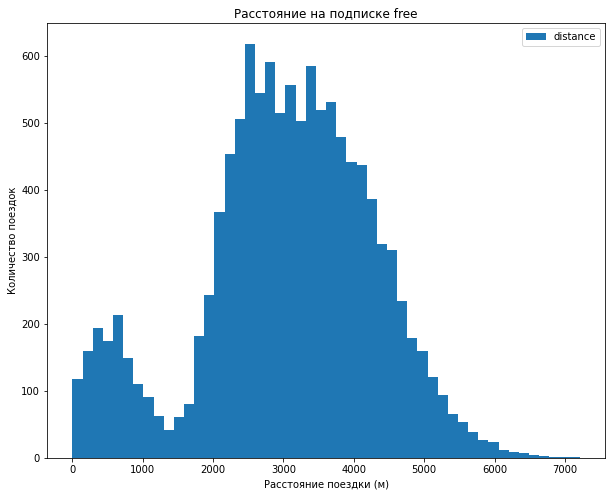

In [34]:
# Визуализируем информацию о расстоянии поездки на подписке free
ax = free_sub.plot(y='distance', 
                   kind='hist', 
                   bins=50, 
                   figsize=(10, 8), 
                   title='Расстояние на подписке free')
ax.set_xlabel('Расстояние поездки (м)')
ax.set_ylabel('Количество поездок')
plt.show()

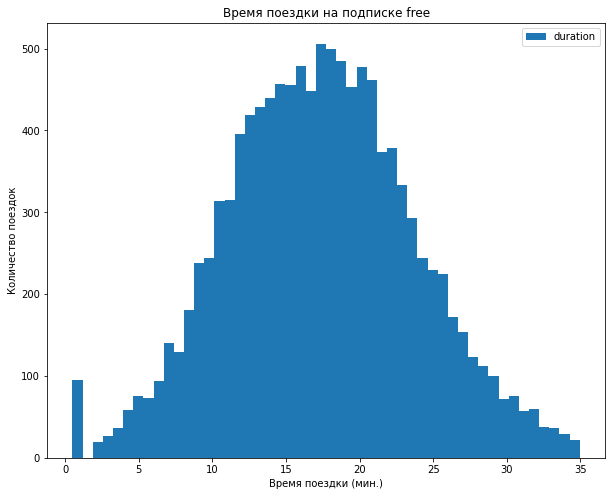

In [35]:
# Визуализируем информацию о времени поездки на подписке free
ax = free_sub.plot(y='duration', 
                   kind='hist', 
                   bins=50, 
                   figsize=(10, 8), 
                   title='Время поездки на подписке free')
ax.set_xlabel('Время поездки (мин.)')
ax.set_ylabel('Количество поездок')
plt.show()

Создадим датафрейм с данными о пользователях с платной подпиской

In [36]:
ultra_sub = full_data.query("`subscription_type` == 'ultra'")
ultra_sub

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,25.599769,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,15.816871,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,6.232113,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,18.511000,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,26.265803,2021-08-28,8,6,0,199
...,...,...,...,...,...,...,...,...,...,...,...,...
6495,699,Оксана,22,Москва,ultra,3973.046497,24.671163,2021-08-29,8,6,0,199
6496,699,Оксана,22,Москва,ultra,3288.702563,15.892886,2021-09-12,9,6,0,199
6497,699,Оксана,22,Москва,ultra,3076.159348,14.389525,2021-09-26,9,6,0,199
6498,699,Оксана,22,Москва,ultra,4707.845501,15.839579,2021-10-17,10,6,0,199


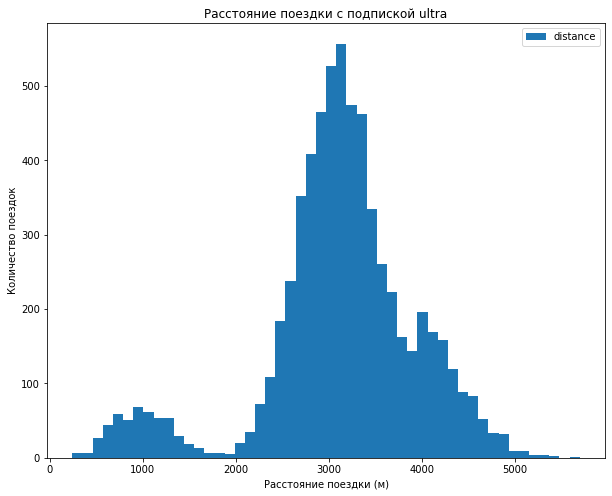

In [37]:
# Визуализируем информацию о расстоянии поездки с подпиской ultra
ax = ultra_sub.plot(y='distance', 
                    kind='hist', 
                    bins=50, 
                    figsize=(10, 8), 
                    title='Расстояние поездки с подпиской ultra')
ax.set_xlabel('Расстояние поездки (м)')
ax.set_ylabel('Количество поездок')
plt.show()

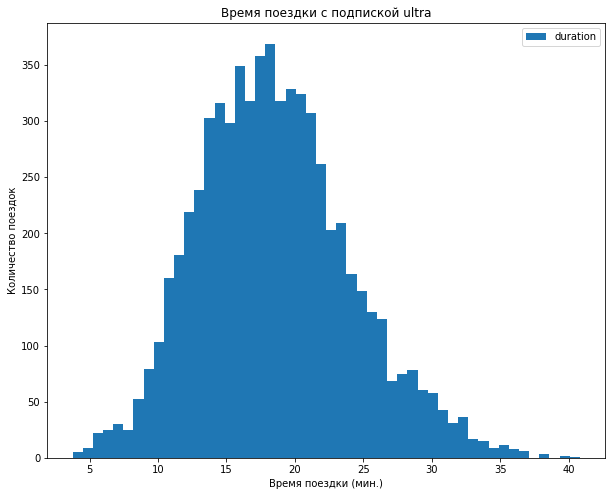

In [38]:
# Визуализируем информацию о времени поездки с подпиской ultra
ax = ultra_sub.plot(y='duration', 
                    kind='hist', 
                    bins=50, 
                    figsize=(10, 8), 
                    title='Время поездки с подпиской ultra')
ax.set_xlabel('Время поездки (мин.)')
ax.set_ylabel('Количество поездок')
plt.show()

Построим наложенные диаграммы для наглядности:

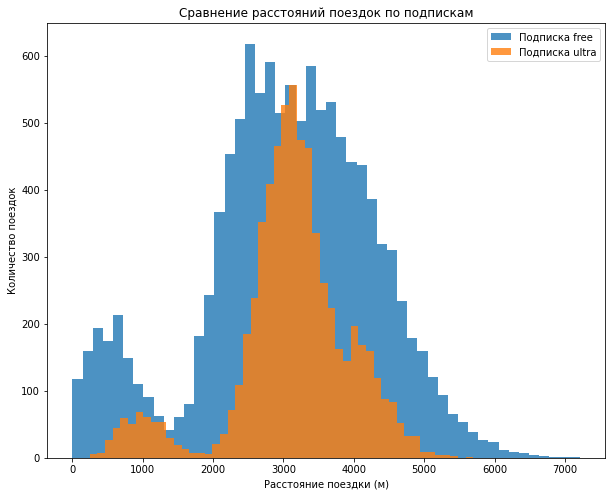

In [39]:
# строим диаграмму расстояний
fig, ax = plt.subplots(figsize=(10, 8))

ax.hist(free_sub['distance'], bins=50, label='Подписка free', alpha=0.8)

ax.hist(ultra_sub['distance'], bins=50, label='Подписка ultra', alpha=0.8)

ax.set_xlabel('Расстояние поездки (м)')
ax.set_ylabel('Количество поездок')
ax.set_title('Сравнение расстояний поездок по подпискам')
plt.legend()
plt.show()

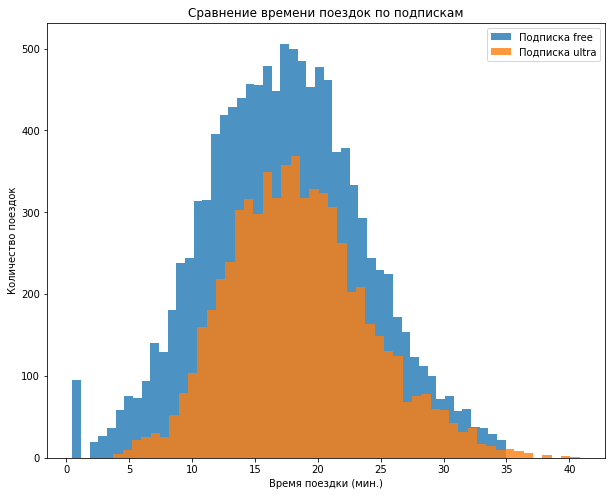

In [40]:
# строим диаграмму времени
fig, ax = plt.subplots(figsize=(10, 8))

ax.hist(free_sub['duration'], bins=50, label='Подписка free', alpha=0.8)

ax.hist(ultra_sub['duration'], bins=50, label='Подписка ultra', alpha=0.8)

ax.set_xlabel('Время поездки (мин.)')
ax.set_ylabel('Количество поездок')
ax.set_title('Сравнение времени поездок по подпискам')
plt.legend()
plt.show()

 Объединили данные о пользователях, поездках и тарифах в один датафрейм - full_data.

Выделили два датафрейма на основе full_data:

free_sub - Информация о пользователях с бесплатным тарифом,
ultra_sub - Информация о пользователях с платным тарифом,

Визуализировали информацию о расстоянии и времени для каждого из тарифов.

Для бесплатного тарифа время поездки составляет от 10 до 25 минут, и проезжают от 2 до 4.5 км, есть пользователи, которые проехали даже 6, 6.5 км.

Платный тариф. В основном время укладывается в промежуток от 12 до 25 минут. Пик расстояния поездки приходится на 3км.

Таким образом, по гистограммам можно сделать вывод, что пользователи с бесплатным тарифом в целом совершают более долгие поездки, а также проезжают большее расстояние, чем пользователи на платном тарифе.

#### Шаг 5. Подсчёт выручки

Найдем суммарное расстояние, количество поeздок и суммарное время для каждого пользователя за каждый месяц

In [41]:
# Округлим значения в исходной таблице
full_data['duration'] = np.ceil(full_data['duration'])
full_data.head()

,user_id,name,age,city,subscription_type,distance,duration,date,month,minute_price,start_ride_price,subscription_fee
0,1,Кира,22,Тюмень,ultra,4409.919140,26.0,2021-01-01,1,6,0,199
1,1,Кира,22,Тюмень,ultra,2617.592153,16.0,2021-01-18,1,6,0,199
2,1,Кира,22,Тюмень,ultra,754.159807,7.0,2021-04-20,4,6,0,199
3,1,Кира,22,Тюмень,ultra,2694.783254,19.0,2021-08-11,8,6,0,199
4,1,Кира,22,Тюмень,ultra,4028.687306,27.0,2021-08-28,8,6,0,199


In [42]:
# Создание сводной таблицы
total_data = full_data.pivot_table(
    index=('user_id', 'month'), 
    values=(
        'distance', 
        'duration', 
        'minute_price', 
        'start_ride_price', 
        'subscription_fee'
    ), 
    aggfunc=('count', 'sum'))



In [43]:
total_data.head()

distance              duration       minute_price      \
                 count          sum    count   sum        count sum   
user_id month                                                         
1       1            2  7027.511294        2  42.0            2  12   
        4            1   754.159807        1   7.0            1   6   
        8            2  6723.470560        2  46.0            2  12   
        10           2  5809.911100        2  32.0            2  12   
        11           3  7003.499363        3  56.0            3  18   

              start_ride_price     subscription_fee       
                         count sum            count  sum  
user_id month                                             
1       1                    2   0                2  398  
        4                    1   0                1  199  
        8                    2   0                2  398  
        10                   2   0                2  398  
        11                   3   0                3  597

Появились дополнительные стобцы в два ряда, нужно переименовать их и удалить лишние, а значения столбцов со стоимостью начала поездки и стоимостью цены вернуть в изначальное состояние т.к. сумму для них находить не нужно.

In [44]:

# Переименование "двухэтажных" названий столбцов
total_data.columns = [
    'count', 'distance', 
    'count2', 'duration', 
    'count3', 'minute_price',
    'count4', 'start_ride_price', 
    'count5', 'subscription_fee'
]
total_data.head()

count     distance  count2  duration  count3  minute_price  \
user_id month                                                               
1       1          2  7027.511294       2      42.0       2            12   
        4          1   754.159807       1       7.0       1             6   
        8          2  6723.470560       2      46.0       2            12   
        10         2  5809.911100       2      32.0       2            12   
        11         3  7003.499363       3      56.0       3            18   

               count4  start_ride_price  count5  subscription_fee  
user_id month                                                      
1       1           2                 0       2               398  
        4           1                 0       1               199  
        8           2                 0       2               398  
        10          2                 0       2               398  
        11          3                 0       3               597

In [45]:
# Удаление столбцов с количеством строк 
total_data = total_data.drop(['count2', 'count3', 'count4', 'count5'], axis=1)

# Приведение столбцов с ценами к целевому состоянию
total_data['start_ride_price'] = total_data['start_ride_price'] / total_data['count']
total_data['minute_price'] = total_data['minute_price'] / total_data['count']
total_data['subscription_fee'] = total_data['subscription_fee'] / total_data['count']

In [46]:

total_data.sort_values(by='month').head(10)

,,count,distance,duration,minute_price,start_ride_price,subscription_fee
user_id,month,,,,,,
1,1,2,7027.511294,42.0,6.0,0.0,199.0
686,1,3,9891.825690,53.0,6.0,0.0,199.0
685,1,2,4837.670420,47.0,6.0,0.0,199.0
682,1,1,2929.820795,25.0,6.0,0.0,199.0
680,1,1,3316.977004,18.0,6.0,0.0,199.0
679,1,2,6407.866143,38.0,6.0,0.0,199.0
675,1,1,3907.983157,21.0,6.0,0.0,199.0
674,1,1,2952.626152,11.0,6.0,0.0,199.0
673,1,1,3371.773487,24.0,6.0,0.0,199.0


In [47]:
# Расчет выручки за месяц
total_data['month_revenue'] = (
    (total_data['start_ride_price'] * total_data['count']) 
    + (total_data['minute_price'] * total_data['duration']) 
    + total_data['subscription_fee']
)

total_data.head(10)

count      distance  duration  minute_price  start_ride_price  \
user_id month                                                                  
1       1          2   7027.511294      42.0           6.0               0.0   
        4          1    754.159807       7.0           6.0               0.0   
        8          2   6723.470560      46.0           6.0               0.0   
        10         2   5809.911100      32.0           6.0               0.0   
        11         3   7003.499363      56.0           6.0               0.0   
        12         2   6751.629942      28.0           6.0               0.0   
2       3          3  10187.723006      63.0           6.0               0.0   
        4          2   6164.381824      40.0           6.0               0.0   
        6          1   3255.338202      14.0           6.0               0.0   
        7          2   6780.722964      48.0           6.0               0.0   

               subscription_fee  month_revenue  
user_id month                                   
1       1                 199.0          451.0  
        4                 199.0          241.0  
        8                 199.0          475.0  
        10                199.0          391.0  
        11                199.0          535.0  
        12                199.0          367.0  
2       3                 199.0          577.0  
        4                 199.0          439.0  
        6                 199.0          283.0  
        7                 199.0          487.0

Создали новый датафрейм с агрегированными данными (total_data) на основе датафрейма с объединенными данными (full_data).

Нашли суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц. Также добавили столбец с помесячной выручкой, которую принес каждый пользователь.

#### Шаг 6. Проверка гипотез

Важно понять, тратят ли пользователи с подпиской больше времени на поездки?

Если да, то пользователи с подпиской могут быть «выгоднее» для компании. Проверим гипотезу. Используем исходные данные о продолжительности каждой сессии — отдельно для подписчиков и тех, у кого нет подписки.

Проверим гипотезу: пользователи с подпиской тратят больше времени на поездки, чем пользователи на бесплатном тарифе.

H_0: Время (duration) пользователей на подписке ultra равно времени (duration) пользователей на подписке free

H_1: Время (duration) пользователей на подписке ultra больше времени (duration) пользователей на подписке free

alpha = 0.05

In [49]:
ultra = ultra_sub['duration'] 

free = free_sub['duration']

results = st.ttest_ind(ultra, free, alternative = 'greater')

alpha = 0.05

print(results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

1.2804098316645618e-34
Отвергаем нулевую гипотезу


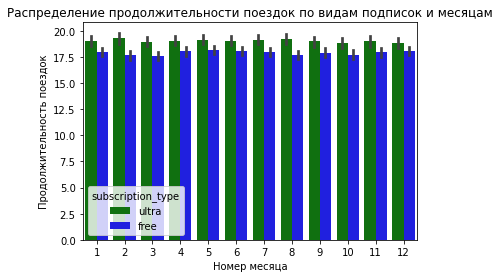

In [50]:
ax = sns.barplot(x = 'month',
            y = 'duration',
            hue = "subscription_type",
            data = full_data,
            palette = ['green', 'blue'])
ax.set_title('Распределение продолжительности поездок по видам подписок и месяцам')
ax.set(xlabel='Номер месяца', ylabel='Продолжительность поездок');

Проведенный t-тест для независимых выборок показал, что среднее время поездок пользователей с подпиской “ultra” значительно больше, чем среднее время поездок пользователей с подпиской “free” (p-value = 1.28e-34 < 0.05).

Таким образом, мы отвергаем нулевую гипотезу о равенстве средних времен поездок и делаем вывод, что пользователи с подпиской “ultra” тратят больше времени на поездки, чем пользователи с подпиской “free”.

Расстояние одной поездки в 3130 метров — оптимальное с точки зрения износа самоката. Можно ли сказать, что расстояние, которое проезжают пользователи с подпиской за одну поездку, не превышает 3130 метров? Проверим гипотезу.

H0: Расстояние пользователей с подпиской равно 3130 метрам

H1: Расстояние пользователей с подпиской больше 3130 метров

In [51]:
ultra_dist = ultra_sub['distance']

interested_value = 3130.0

alpha = 0.05

results = st.ttest_1samp(
    ultra_dist, 
    interested_value,
    alternative='greater')
    
print(results.pvalue)

if (results.pvalue < alpha):
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

0.9195368847849785
Не удалось отвергнуть нулевую гипотезу


Проведенный одновыборочный t-тест показал, что среднее расстояние поездок пользователей с подпиской “ultra” не отличается от заданного значения 3130 метров (p-value = 0.9195 > 0.05).

Таким образом, мы не можем отвергнуть нулевую гипотезу и делаем вывод, что среднее расстояние поездок с использованием подписки 'ultra' (меньше или) равно 3130 метров.

Проверим гипотезу Выручка от пользователей с подпиской выше, чем выручка от пользователей без подписки

H0: Выручка от пользователей с подпиской равна выручке от пользователей без подписки

H1: Выручка от пользователей с подпиской больше выручки от пользователей без подписки

In [52]:
ultra_per_month = total_data.loc[total_data.subscription_fee == 199, 'month_revenue'] 

free_per_month = total_data.loc[total_data.subscription_fee == 0, 'month_revenue'] 


results = st.ttest_ind(ultra_per_month, 
                       free_per_month,
                       alternative = 'greater')

alpha = 0.05

print(results.pvalue)

if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не удалось отвергнуть нулевую гипотезу')

1.8850394384715216e-31
Отвергаем нулевую гипотезу


Проведенный t-тест для независимых выборок показал, что средняя выручка от пользователей с подпиской значительно выше, чем средняя выручка от пользователей без подписки (p-value = 1.89e-31 < 0.05).

Полученные результаты наводят на мысль о том, что выручка от пользователей с подпиской действительно выше, чем выручка от пользователей без подписки.

Важно помнить, что это лишь один из способов анализа данных, и для более полной картины необходимо учесть и другие факторы, например, характеристики пользователей в каждой группе.

Разберем ситуацию: техническая команда сервиса обновила сервера, с которыми взаимодействует мобильное приложение. Она надеется, что из-за этого количество обращений в техподдержку значимо снизилось. Некоторый файл содержит для каждого пользователя данные о количестве обращений до обновления и после него. Какой тест вам понадобился бы для проверки этой гипотезы?

Ответ: в данном случае у нас две зависимые(парные) выборки, т.к. данные собраны для одних и тех же пользователей до и после обновления. А значит нужно использовать двухвыборочный t-тест для зависимых выборок scipy.stats.ttest_rel() с параметром alternative='less' т.к. поддержка надеется, что количество обращений снизилось, следовательно проверить надо левостороннюю гипотезу.

**Общий вывод**

Загрузили три датафрейма: с пользователями, информацией о поездках, информацией о подписках. Пропусков в данных не оказалось. Поменяли тип данных у столбца date из датафрейма rides к типу даты pandas. Также добавили столбец month с номером месяца. И удалили 31 дубликат строк из датафрейма с пользователями.

Провели исследовательский анализ данных:

Выяснили, что количество пользователей по городам распределено примерно одинаково, нет выдающихся значений. Лидером по количеству пользователей является Пятигорск - 219 пользователей. Меньше всего пользователей в Москве - 168.
Пользователей, использующих бесплатную подписку больше - 835 человек, что является ~54% от общего числа пользователей. На платной подписке сидит 699 пользователей, что соответственно является ~46%.
Возраст пользователей укладывается в промежуток от 20 до 30 лет, больше всего 25 летних пользователей.
В основном пользователи проезжают от 2.5 км до 4 км.
Чаще всего длительность поездки состовляет 13 - 22 минут

Объединили данные о пользователях, поездках и подписках в один датафрейм. На основе объединенного датафрейма создали еще 2 датафрейма:

Для пользователей с ultra подпиской
Для пользователей с free подпиской
Дальше визуализировали информацию о расстоянии и времени поездки для пользоватей каждого тарифа.

Для бесплатного тарифа время поездки составляет от 10 до 25 минут, и проезжают от 2 до 4.5 км, есть пользователи, которые проехали даже 6, 6.5 км.
Платный тариф. В основном время укладывается в промежуток от 12 до 25 минут. Пик расстояния поездки приходится на 3км.
Сделали вывод, что пользователи с бесплатной подпиской совершают более длительные и дальние поездки, чем, пользователи с платной подпиской.
Нашли суммарное расстояние, количество поездок и суммарное время для каждого пользователя за каждый месяц - вывели все данные в отдельный датафрейм total_data. Добавили в датафрейм total_data столбец с помесячной выручкой month_revenue.

Проверка гипотез
В результате проверки получили основания предполагать, что пользователи с подпиской “ultra” отличаются от пользователей без подписки по ряду ключевых показателей:
Время поездок: Пользователи с подпиской “ultra” тратят заметно больше времени на поездки, чем пользователи без подписки.
Расстояние поездок: Среднее расстояние поездок пользователей с подпиской “ultra” не отличается от 3130 метров.
Выручка: Выручка от пользователей с подпиской значительно выше, чем выручка от пользователей без подписки.

С большой вероятностью можно утверждать, что пользователи с подпиской “ultra” более выгодны для компании. Хотя расстояние поездок у них не сильно отличается от заданного значения 3130 метров, они тратят больше времени на поездки, что приводит к более высокой выручке, так что стоит стимулировать пользователей переходить на платную подписку. А также для улучшения анализа нужно собрать информацию о стоимости обслуживания самокатов, т.к. есть вероятность, что пользователи с платной подпиской в результате активного использования самокатов влекут и повышенные расходы на обслуживание.